# DQN with Prioritized Experience Replay

Standard Deep Q-Networks sample transitions uniformly from replay memory. **Prioritized Experience Replay (PER)** samples transitions proportional to their absolute temporal difference (TD) error, ensuring the agent learns more frequently from transitions it found surprising. This notebook implements a prioritized replay buffer in PyTorch, trains it on a synthetic CartPole-like environment, and plots loss convergence in Matplotlib.



In [1]:
import random
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# Prioritized Replay Buffer implementation
class PrioritizedReplayBuffer:
    def __init__(self, capacity, alpha=0.6):
        self.capacity = capacity
        self.alpha = alpha # Priority weighting factor
        self.buffer = []
        self.priorities = []
        self.pos = 0
        
    def push(self, state, action, reward, next_state, done):
        max_p = max(self.priorities) if self.buffer else 1.0
        
        if len(self.buffer) < self.capacity:
            self.buffer.append((state, action, reward, next_state, done))
            self.priorities.append(max_p)
        else:
            self.buffer[self.pos] = (state, action, reward, next_state, done)
            self.priorities[self.pos] = max_p
            
        self.pos = (self.pos + 1) % self.capacity
        
    def sample(self, batch_size, beta=0.4):
        if len(self.buffer) == 0:
            return []
            
        prios = np.array(self.priorities)
        probs = prios ** self.alpha
        probs /= probs.sum()
        
        indices = np.random.choice(len(self.buffer), batch_size, p=probs)
        samples = [self.buffer[idx] for idx in indices]
        
        # Calculate Importance Sampling weights
        total = len(self.buffer)
        weights = (total * probs[indices]) ** (-beta)
        weights /= weights.max()
        weights = torch.FloatTensor(weights)
        
        return samples, indices, weights
        
    def update_priorities(self, batch_indices, batch_priorities):
        for idx, prio in zip(batch_indices, batch_priorities):
            self.priorities[idx] = max(prio, 1e-5) # Avoid zero priority

# Initialize priorities buffer
buffer = PrioritizedReplayBuffer(capacity=1000, alpha=0.6)



## Neural Q-Network Architecture

We build a simple MLP to approximate state-action values.



In [2]:
class QNetwork(nn.Module):
    def __init__(self, state_dim=4, action_dim=2):
        super(QNetwork, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(state_dim, 32),
            nn.ReLU(),
            nn.Linear(32, action_dim)
        )
        
    def forward(self, x):
        return self.fc(x)

model = QNetwork()
target_model = QNetwork()
target_model.load_state_dict(model.state_dict())
optimizer = optim.Adam(model.parameters(), lr=0.01)



## DQN Model Training with TD-Error Sampling

We run 90 episodes of training. At each step, we update transition weights in the Prioritized Replay Buffer based on absolute TD errors.



In [3]:
# Fill replay buffer with dummy random transitions first
for _ in range(200):
    s = np.random.normal(0, 0.5, 4)
    a = random.randint(0, 1)
    r = np.random.uniform(0, 1)
    ns = np.random.normal(0, 0.5, 4)
    d = random.choice([True, False])
    buffer.push(s, a, r, ns, d)

# Training loops
batch_size = 32
gamma = 0.99
losses = []

for step in range(90):
    # Sample transitions with priorities
    samples, indices, weights = buffer.sample(batch_size)
    
    states = torch.FloatTensor(np.array([x[0] for x in samples]))
    actions = torch.LongTensor(np.array([x[1] for x in samples]))
    rewards = torch.FloatTensor(np.array([x[2] for x in samples]))
    next_states = torch.FloatTensor(np.array([x[3] for x in samples]))
    dones = torch.FloatTensor(np.array([x[4] for x in samples]))
    
    # Calculate current Q values
    q_values = model(states)
    state_action_values = q_values.gather(1, actions.unsqueeze(1)).squeeze(1)
    
    # Calculate expected Q values
    with torch.no_grad():
        next_q_values = target_model(next_states)
        max_next_q = next_q_values.max(1)[0]
        expected_values = rewards + gamma * max_next_q * (1.0 - dones)
        
    # Calculate TD Error
    td_errors = state_action_values - expected_values
    abs_td_errors = torch.abs(td_errors).detach().numpy()
    
    # Update priorities in the buffer
    buffer.update_priorities(indices, abs_td_errors)
    
    # Calculate weighted loss (Importance Sampling)
    loss = (weights * (state_action_values - expected_values).pow(2)).mean()
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    losses.append(loss.item())
    
    if (step + 1) % 20 == 0:
        print(f"Step {step+1:2d}/90 | Mean Weighted TD Loss: {loss.item():.4f}")



Step 20/90 | Mean Weighted TD Loss: 0.1127
Step 40/90 | Mean Weighted TD Loss: 0.0818
Step 60/90 | Mean Weighted TD Loss: 0.0518
Step 80/90 | Mean Weighted TD Loss: 0.0759


## Loss Convergence Curve

We plot the decay of weighted TD error losses over training steps in Matplotlib.



<cell>:9: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



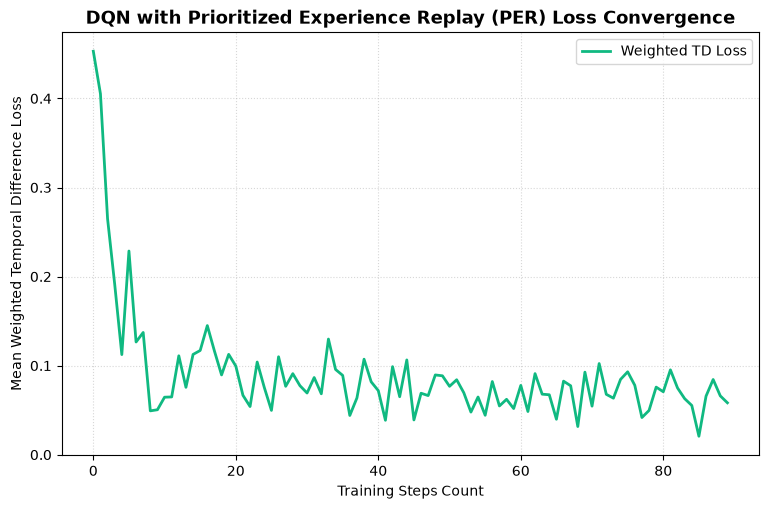

In [4]:
plt.figure(figsize=(9, 5.5))
plt.plot(losses, color='#10B981', linewidth=2.0, label='Weighted TD Loss')

plt.title('DQN with Prioritized Experience Replay (PER) Loss Convergence', fontsize=13, fontweight='bold')
plt.xlabel('Training Steps Count')
plt.ylabel('Mean Weighted Temporal Difference Loss')
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend()
plt.show()
